In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, recall_score

In [2]:
park_agg = pd.read_csv("../data/clean/park_agg.csv")
park_agg.head()

,Park Name,Recreation Visits,Non Recreation Visits,Recreation Hours,Non Recreation Hours,Concessioner Lodging,Concessioner Camping,Tent Campers,RV Campers,Backcountry,Non Recreation Overnight Stays,Miscellaneous Overnight Stays,Number of Activities,Entrance Fees
0,Acadia NP,297181.590909,3925.000000,1.931537e+06,3925.000000,0.000000,104.825758,10320.848485,3754.424242,106.265152,0.0,698.704545,46.0,6.0
1,Arches NP,127372.462121,125.484848,5.245314e+05,125.484848,0.000000,0.000000,1339.030303,1406.000000,32.174242,0.0,457.840909,18.0,30.0
2,Badlands NP,86726.174242,5311.272727,3.805244e+05,5311.272727,802.356061,2125.492424,325.030303,72.454545,192.409091,0.0,6.598485,21.0,30.0
3,Big Bend NP,39713.340909,207.181818,8.469260e+05,207.181818,2717.181818,616.053030,4288.750000,2258.462121,3197.219697,0.0,2354.234848,24.0,30.0
4,Biscayne NP,45659.689394,0.000000,1.457889e+05,0.000000,0.000000,0.000000,128.962121,0.000000,0.000000,0.0,238.113636,24.0,0.0


In [ ]:
#creatin target variable ' High Crowding' 1 = high crowding 0 = low crowding
park_agg['High_Crowding'] = (park_agg['Recreation Visits'] > park_agg['Recreation Visits'].median()).astype(int)
features = ['Concessioner Lodging','Concessioner Camping','Tent Campers','RV Campers','Backcountry','Miscellaneous Overnight Stays','Number of Activities','Entrance Fees']
target = 'High_Crowding'
display(park_agg[features].head())
display(park_agg[[target]].head())

,Concessioner Lodging,Concessioner Camping,Tent Campers,RV Campers,Backcountry,Miscellaneous Overnight Stays,Number of Activities,Entrance Fees
0,0.000000,104.825758,10320.848485,3754.424242,106.265152,698.704545,46.0,6.0
1,0.000000,0.000000,1339.030303,1406.000000,32.174242,457.840909,18.0,30.0
2,802.356061,2125.492424,325.030303,72.454545,192.409091,6.598485,21.0,30.0
3,2717.181818,616.053030,4288.750000,2258.462121,3197.219697,2354.234848,24.0,30.0
4,0.000000,0.000000,128.962121,0.000000,0.000000,238.113636,24.0,0.0


,High_Crowding
0,1
1,1
2,1
3,0
4,0


In [ ]:
park_agg['High_Crowding'] =(park_agg['Recreation Visits'] >park_agg['Recreation Visits'].median()).astype(int)
park_agg.to_csv('../data/clean/park_agg_for_svm.csv', index=False)

In [ ]:
X_train, X_test, y_train,y_test=train_test_split(park_agg[features],park_agg[target],test_size=0.25,random_state=12,stratify=park_agg[target])
display(pd.DataFrame(X_train).head())
display(pd.DataFrame(y_train).head())
display(pd.DataFrame(X_test).head())
display(pd.DataFrame(y_test).head())

,Concessioner Lodging,Concessioner Camping,Tent Campers,RV Campers,Backcountry,Miscellaneous Overnight Stays,Number of Activities,Entrance Fees
1,0.000000,0.000000,1339.030303,1406.0,32.174242,457.840909,18.0,30.0
45,0.000000,0.000000,0.000000,0.0,66.742424,0.000000,37.0,25.0
20,1054.886364,0.000000,58.219697,0.0,358.583333,992.893939,31.0,0.0
34,345.901515,0.000000,275.030303,0.0,356.113636,0.530303,23.0,0.0
51,506.825758,583.916667,0.000000,0.0,0.000000,2111.560606,31.0,0.0


,High_Crowding
1,1
45,0
20,0
34,0
51,0


,Concessioner Lodging,Concessioner Camping,Tent Campers,RV Campers,Backcountry,Miscellaneous Overnight Stays,Number of Activities,Entrance Fees
46,0.0,2126.30303,0.000000,0.000000,0.000000,0.000000,26.0,30.0
24,0.0,0.00000,2053.265152,1497.893939,36.151515,115.924242,35.0,0.0
30,0.0,0.00000,156.742424,2278.969697,0.000000,0.000000,20.0,0.0
5,0.0,0.00000,1377.848485,988.250000,138.363636,0.000000,26.0,30.0
33,0.0,0.00000,17376.303030,6848.090909,1340.234848,5600.818182,29.0,30.0


,High_Crowding
46,0
24,0
30,1
5,0
33,1


In [ ]:
sc =StandardScaler()
X_train =sc.fit_transform(X_train)
display(pd.DataFrame(X_train,columns=features).head())

,Concessioner Lodging,Concessioner Camping,Tent Campers,RV Campers,Backcountry,Miscellaneous Overnight Stays,Number of Activities,Entrance Fees
0,-0.386858,-0.256921,-0.333145,-0.175538,-0.497088,-0.212332,-1.224241,0.810378
1,-0.386858,-0.256921,-0.579446,-0.578080,-0.489011,-0.648262,0.461863,0.462169
2,-0.300744,-0.256921,-0.568737,-0.578080,-0.420819,0.297115,-0.070590,-1.278878
3,-0.358621,-0.256921,-0.528857,-0.578080,-0.421396,-0.647757,-0.780529,-1.278878
4,-0.345484,-0.178057,-0.579446,-0.578080,-0.504606,1.362246,-0.070590,-1.278878


In [ ]:
#testing out different cost values
costs = [.1, 1, 10]
kernels = ['linear','poly','rbf']
results = []
for kernel in kernels:
    for c in costs:
        if kernel =='poly':
            model = SVC(kernel=kernel, degree=2, C=c)
        else:
            model = SVC(kernel=kernel, C=c)
        model.fit(X_train, y_train)
        y_pred = model.predict(sc.transform(X_test))
        acc = accuracy_score(y_test, y_pred)
        results.append({'Kernel': kernel,'Cost': c,'Accuracy': acc})
cost_results = pd.DataFrame(results)
display(cost_results)

,Kernel,Cost,Accuracy
0,linear,0.1,0.400000
1,linear,1.0,0.400000
2,linear,10.0,0.400000
3,poly,0.1,0.533333
4,poly,1.0,0.600000
5,poly,10.0,0.533333
6,rbf,0.1,0.400000
7,rbf,1.0,0.466667
8,rbf,10.0,0.466667


In [45]:
classifier_linear = SVC(kernel='linear', C=10)
classifier_poly = SVC(kernel='poly', degree=2, C=1)
classifier_rbf = SVC(kernel='rbf', C=1)
classifier_linear.fit(X_train,y_train)
classifier_poly.fit(X_train, y_train)
classifier_rbf.fit(X_train,y_train)
pred_linear = classifier_linear.predict(sc.transform(X_test))
pred_poly =classifier_poly.predict(sc.transform(X_test))
pred_rbf= classifier_rbf.predict(sc.transform(X_test))

Text(0.5, 1.0, 'SVM Confusion Matrix - Linear Kernel')

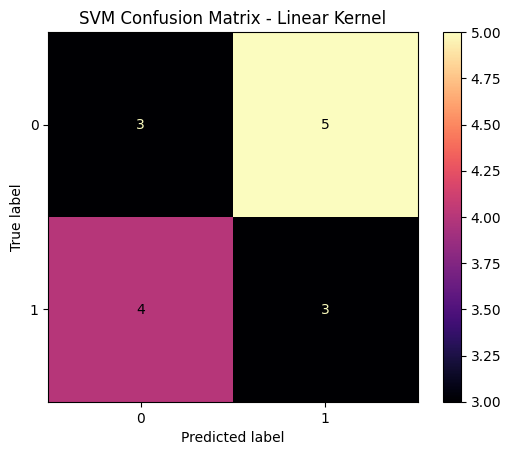

In [46]:
#confusion matrix - linear kernel
cm_linear =confusion_matrix(y_test,pred_linear)
disp =ConfusionMatrixDisplay(confusion_matrix=cm_linear,display_labels=classifier_linear.classes_)
disp.plot(cmap='magma')
disp.ax_.set_title('SVM Confusion Matrix - Linear Kernel')

Text(0.5, 1.0, 'SVM Confusion Matrix - Polynomial Kernel')

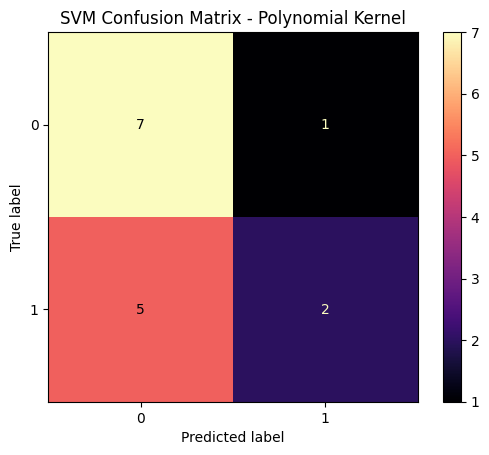

In [47]:
#confusion matrix - polynomial kernel
cm_poly= confusion_matrix(y_test, pred_poly)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_poly,display_labels=classifier_poly.classes_)
disp.plot(cmap='magma')
disp.ax_.set_title('SVM Confusion Matrix - Polynomial Kernel')

Text(0.5, 1.0, 'SVM Confusion Matrix - RBF Kernel')

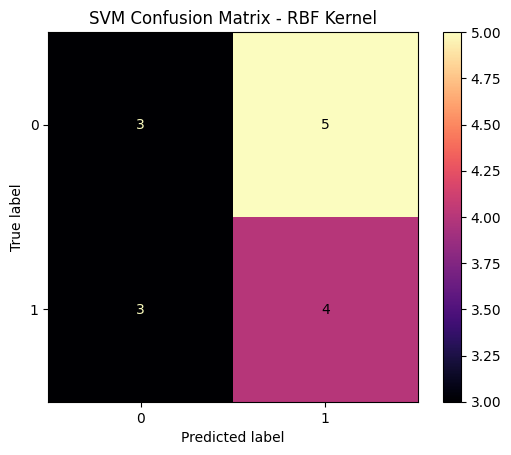

In [48]:
#confusion matrix - RBF kernel
cm_rbf = confusion_matrix(y_test, pred_rbf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rbf,display_labels=classifier_rbf.classes_)
disp.plot(cmap='magma')
disp.ax_.set_title('SVM Confusion Matrix - RBF Kernel')

In [49]:
#calculating accuracy
accuracy_linear = accuracy_score(y_test, pred_linear)
accuracy_poly= accuracy_score(y_test, pred_poly)
accuracy_rbf =accuracy_score(y_test, pred_rbf)
scores = pd.DataFrame({'Kernel': ['Linear', 'Polynomial', 'RBF'],'Accuracy': [accuracy_linear, accuracy_poly, accuracy_rbf]})
display(scores)

,Kernel,Accuracy
0,Linear,0.400000
1,Polynomial,0.600000
2,RBF,0.466667
